Observations : 1350
Rats         : 90

Fitting...
  [Model 1] converged: powell
  [Model 2] converged: powell

MODEL 1 — TDS + Week (no intake)
  Intercept                       β=+25.937  [+24.773,+27.101]  p=0.0000 ***
  TDS (per 1 SD ≈ 150 mg/L)       β=+0.551  [-0.441,+1.542]  p=0.2762 ns
  Week                            β=-1.917  [-1.993,-1.841]  p=0.0000 ***

  ICC  = 0.349  (34.9% between-rat variance)
  AIC  = 8957.3

MODEL 2 — TDS + Feed Intake + Week
  Intercept                       β=+27.238  [+26.010,+28.467]  p=0.0000 ***
  TDS (per 1 SD ≈ 150 mg/L)       β=+0.301  [-0.457,+1.059]  p=0.4368 ns
  Feed intake (per 1 SD)          β=+1.804  [+0.757,+2.852]  p=0.0007 ***
  Week                            β=-2.080  [-2.202,-1.958]  p=0.0000 ***

  ICC  = 0.207  (20.7% between-rat variance)
  AIC  = 8949.6

────────────────────────────────────────────────────────────
KEY COMPARISON — TDS effect before vs after intake
────────────────────────────────────────────────────────────


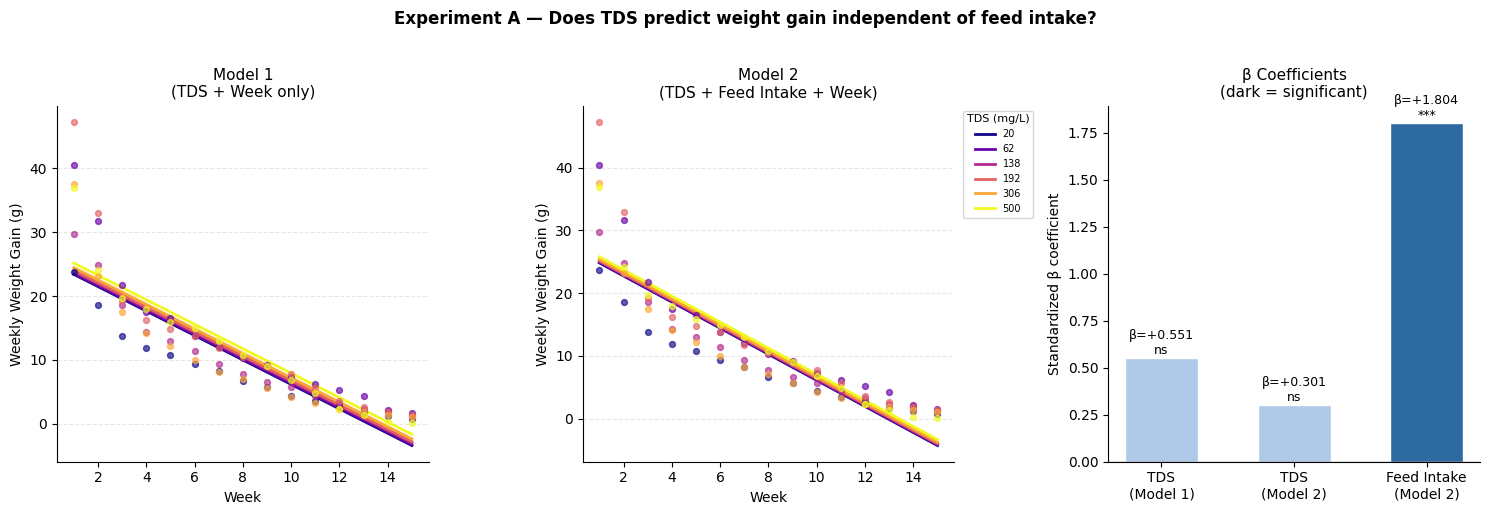

In [4]:
"""
Experiment A — Does TDS predict weight gain independent of feed intake?
=======================================================================
Model 1: weekly_weight_gain ~ TDS + week + (1|rat)
Model 2: weekly_weight_gain ~ TDS + feed_intake + week + (1|rat)

Core question: Does TDS survive as a predictor once we account for
how much the rat actually ate?
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0.  LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv("data/processed_rat_data.csv")   # <── change path

TDS_MAP = {
    "Group 1 (RO water with < 20 TDS)":                                                             20,
    "Group 7 (RO water <20 with alternate day fasting (feed withdrawal))":                          20,
    "Group 2 (RO water with 50-75 TDS)":                                                            62.5,
    "Group 3 (RO water with 125 - 150 TDS)":                                                        137.5,
    "Group 11 (RO Water 125 - 150 TDS with alternate day fasting)":                                 137.5,
    "Group 4 (Telugu Ganga water supplied to Tirupati)":                                            192,
    "Group 5 (Kalyani Dam water supplied to Tirupati)":                                             306,
    "Group 8 (Kalyani Dam water supplied to Tirupati with alternate day fasting (feed withdrawal))": 306,
    "Group 9 (water prepared as per BIS)":                                                          500,
}

df["TDS_numeric"] = df["water_group"].map(TDS_MAP)
df_model = df.dropna(subset=["TDS_numeric"]).copy()
df_model["TDS_numeric"]        = df_model["TDS_numeric"].astype(float)
df_model["week"]               = df_model["week"].astype(float)
df_model["weekly_feed_intake"] = df_model["weekly_feed_intake"].astype(float)

# Standardize so β values are directly comparable to each other
tds_mean  = df_model["TDS_numeric"].mean()
tds_std   = df_model["TDS_numeric"].std()
feed_mean = df_model["weekly_feed_intake"].mean()
feed_std  = df_model["weekly_feed_intake"].std()

df_model["TDS_z"]  = (df_model["TDS_numeric"]       - tds_mean) / tds_std
df_model["feed_z"] = (df_model["weekly_feed_intake"] - feed_mean) / feed_std

print(f"Observations : {len(df_model)}")
print(f"Rats         : {df_model['unique_rat_id'].nunique()}\n")

# ─────────────────────────────────────────────
# 1.  FIT MODELS
# ─────────────────────────────────────────────
def fit(formula, label):
    for method in ["powell", "lbfgs", "nm", "bfgs"]:
        try:
            res = smf.mixedlm(
                formula, data=df_model,
                groups=df_model["unique_rat_id"]
            ).fit(method=method, reml=False, maxiter=1000)
            if res.converged:
                print(f"  [{label}] converged: {method}")
                return res
        except Exception:
            continue
    raise RuntimeError(f"{label} — no optimizer converged")

print("Fitting...")
m1 = fit("weekly_weight_gain ~ TDS_z + week",           "Model 1")
m2 = fit("weekly_weight_gain ~ TDS_z + feed_z + week",  "Model 2")
print()

# ─────────────────────────────────────────────
# 2.  CLEAN RESULTS TABLE
# ─────────────────────────────────────────────
def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

def summarise(result, label):
    print("=" * 60)
    print(label)
    print("=" * 60)
    params = result.fe_params
    pvals  = result.pvalues
    conf   = result.conf_int()
    rename = {
        "Intercept": "Intercept",
        "TDS_z":     "TDS (per 1 SD ≈ 150 mg/L)",
        "feed_z":    "Feed intake (per 1 SD)",
        "week":      "Week",
    }
    for key in params.index:
        b  = params[key]
        p  = pvals[key]
        lo = conf.loc[key, 0]
        hi = conf.loc[key, 1]
        name = rename.get(key, key)
        print(f"  {name:<30}  β={b:+.3f}  [{lo:+.3f},{hi:+.3f}]  p={p:.4f} {sig(p)}")
    rand_var  = result.cov_re.values[0][0]
    resid_var = result.scale
    icc = rand_var / (rand_var + resid_var)
    print(f"\n  ICC  = {icc:.3f}  ({icc*100:.1f}% between-rat variance)")
    print(f"  AIC  = {result.aic:.1f}\n")

summarise(m1, "MODEL 1 — TDS + Week (no intake)")
summarise(m2, "MODEL 2 — TDS + Feed Intake + Week")

# ─────────────────────────────────────────────
# 3.  THE KEY COMPARISON
# ─────────────────────────────────────────────
b1_tds = m1.fe_params["TDS_z"];  p1_tds = m1.pvalues["TDS_z"]
b2_tds = m2.fe_params["TDS_z"];  p2_tds = m2.pvalues["TDS_z"]
b2_feed = m2.fe_params["feed_z"]; p2_feed = m2.pvalues["feed_z"]

lrt   = 2 * (m2.llf - m1.llf)
lrt_p = stats.chi2.sf(lrt, df=1)

print("─" * 60)
print("KEY COMPARISON — TDS effect before vs after intake")
print("─" * 60)
print(f"  TDS without intake control : β={b1_tds:+.3f}  p={p1_tds:.4f} {sig(p1_tds)}")
print(f"  TDS with    intake control : β={b2_tds:+.3f}  p={p2_tds:.4f} {sig(p2_tds)}")
print(f"  Feed intake (in Model 2)   : β={b2_feed:+.3f}  p={p2_feed:.4f} {sig(p2_feed)}")
print(f"\n  Model improvement (LRT)    : χ²(1)={lrt:.2f}  p={lrt_p:.4f} {sig(lrt_p)}")
print(f"  AIC Model 1 → Model 2      : {m1.aic:.1f} → {m2.aic:.1f}")
print()

# Auto-interpret
if p1_tds >= 0.05 and p2_tds >= 0.05:
    print("  → TDS is not significant in either model.")
    print("    Water mineral content does not independently predict weight gain.")
elif p1_tds < 0.05 and p2_tds >= 0.05:
    print("  → TDS loses significance after controlling for feed intake.")
    print("    TDS effect is MEDIATED by eating behavior — water type affects")
    print("    how much rats eat, and that drives weight gain, not TDS directly.")
elif p1_tds < 0.05 and p2_tds < 0.05:
    pct = (abs(b2_tds) - abs(b1_tds)) / abs(b1_tds) * 100
    print(f"  → TDS remains significant after controlling for feed intake (β change: {pct:+.1f}%).")
    print("    TDS has a DIRECT effect on weight gain beyond feeding behavior.")
else:
    print("  → TDS becomes significant only after controlling for intake (suppression).")

# ─────────────────────────────────────────────
# 4.  PLOT — 3 panels only
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

weeks    = np.arange(1, 16)
tds_vals = [20, 62.5, 137.5, 192, 306, 500]
tds_labs = {20:"20", 62.5:"62.5", 137.5:"137.5", 192:"192", 306:"306", 500:"500"}
cmap     = plt.get_cmap("plasma")
colors   = [cmap(i / (len(tds_vals)-1)) for i in range(len(tds_vals))]

obs = (df_model.groupby(["TDS_numeric","week"])["weekly_weight_gain"]
       .mean().reset_index())

# Panel 1 — Model 1 predicted vs observed
ax = axes[0]
for tds, color in zip(tds_vals, colors):
    tds_s = (tds - tds_mean) / tds_std
    pred  = m1.fe_params["Intercept"] + m1.fe_params["TDS_z"]*tds_s + m1.fe_params["week"]*weeks
    ob    = obs[obs["TDS_numeric"]==tds].sort_values("week")
    ax.plot(weeks, pred, color=color, linewidth=2, label=f"{tds:.0f}")
    ax.scatter(ob["week"], ob["weekly_weight_gain"], color=color, s=18, alpha=0.65, zorder=3)
ax.set_title("Model 1\n(TDS + Week only)", fontsize=11)
ax.set_xlabel("Week"); ax.set_ylabel("Weekly Weight Gain (g)")
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Panel 2 — Model 2 predicted vs observed (feed_z held at 0 = mean intake)
ax2 = axes[1]
for tds, color in zip(tds_vals, colors):
    tds_s = (tds - tds_mean) / tds_std
    pred  = (m2.fe_params["Intercept"] + m2.fe_params["TDS_z"]*tds_s
             + m2.fe_params["feed_z"]*0 + m2.fe_params["week"]*weeks)
    ob    = obs[obs["TDS_numeric"]==tds].sort_values("week")
    ax2.plot(weeks, pred, color=color, linewidth=2, label=f"{tds:.0f}")
    ax2.scatter(ob["week"], ob["weekly_weight_gain"], color=color, s=18, alpha=0.65, zorder=3)
ax2.set_title("Model 2\n(TDS + Feed Intake + Week)", fontsize=11)
ax2.set_xlabel("Week"); ax2.set_ylabel("Weekly Weight Gain (g)")
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax2.legend(title="TDS (mg/L)", fontsize=7, title_fontsize=8,
           bbox_to_anchor=(1.01,1), loc="upper left")
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Panel 3 — TDS β before vs after (the key result)
ax3 = axes[2]
bar_vals   = [b1_tds, b2_tds, b2_feed]
bar_labels = ["TDS\n(Model 1)", "TDS\n(Model 2)", "Feed Intake\n(Model 2)"]
bar_ps     = [p1_tds, p2_tds, p2_feed]
bar_colors = ["#2d6a9f" if p < 0.05 else "#b0c9e8" for p in bar_ps]
bars = ax3.bar(bar_labels, bar_vals, color=bar_colors, edgecolor="white", width=0.55)
ax3.axhline(0, color="gray", linewidth=1)
for bar, b, p in zip(bars, bar_vals, bar_ps):
    ypos = b + 0.02 if b >= 0 else b - 0.07
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f"β={b:+.3f}\n{sig(p)}", ha="center", fontsize=9)
ax3.set_ylabel("Standardized β coefficient", fontsize=10)
ax3.set_title("β Coefficients\n(dark = significant)", fontsize=11)
ax3.spines[["top","right"]].set_visible(False)

plt.suptitle("Experiment A — Does TDS predict weight gain independent of feed intake?",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("experimentA_simplified.png", dpi=150, bbox_inches="tight")
print("Plot saved → experimentA_simplified.png")
plt.show()